**Исходные данные:**
 - У нас есть исторические данные по отликам пользователей в нашем продукте.
 - Мы хотим увеличить долю пользователей с более 10 откликами на 4% (т.е. конверсию пользователей в 11 откликов)
 - Таже хотим увеличить среднее число откликов на пользователя на 6%
 - Пропорция групп - 50/50, Уровень значимости – 20%, Мощность – 80% **± 1пп**


**Задача:**
- Необходимо задизайнить эксперимент и ответить на вопрос **"Сколько пользователей понадобится в одну экспериметальную группу** чтобы она учитывала установленные MDE для двух метрик"? 
- Для конверсии пользователей в 11 откликов надо посчитать результаты для **T-test**
- Для среднего числа откликов на пользователя надо посчитать результаты для **MW-test** 

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

import math

In [ ]:
# df = pd.read_excel("https://drive.google.com/uc?export=download&id=1B_l-rdeNMb7kW2FwRk9UFMx2adm-PWll")
df = pd.read_excel('cnt_by_month.xlsx')
df['is_over_10_answer'] = np.where(df['cnt_answer']>10, 1, 0)

In [3]:
print('дублей в id_client:', sum(df['id_client'].duplicated()))
df.head()

дублей в id_client: 19


,id_client,cnt_answer,is_over_10_answer
0,10361440,51,1
1,10420534,66,1
2,10373595,153,1
3,10184815,179,1
4,10338354,91,1


In [4]:
# в датафрейме есть дубли. возьму max значение cnt_answer для них и соответственно max is_over_1_answer
df = df.groupby('id_client', as_index=False)[['cnt_answer', 'is_over_10_answer']].max()

In [ ]:
# Я решил, что лучше потренируюсь и получу число наблюдений в одной выборке экспериментально. + формула из семинара нам не подходит, т.к. alpha=0.2

alpha = 0.2
beta = 0.2
target_power = 0.8

def get_iter_sample_size(signals, n, mde, stat_test, alpha=0.05):
  pval_list = []

  for _ in range(4000):
    smpl_0 = np.random.choice(signals, size=n, replace=True)
    smpl_1 = np.random.choice(signals, size=n, replace=True)

    smpl_1 = smpl_1 + mde

    p_value = stat_test(smpl_0, smpl_1)
    pval_list.append(p_value)

  pval_list = np.array(pval_list)
  power = np.sum(pval_list<alpha) / len(pval_list)

  return power

def t_test(s1, s2):
  return stats.ttest_ind(s1, s2)[1]

def mw_test(s1, s2):
  return stats.mannwhitneyu(s1,s2)[1]

In [6]:
p0 = df['is_over_10_answer'].mean()
mde_abs_conv = p0 * 0.04


mean0 = df['cnt_answer'].mean()
mde_abs_mean = mean0 * 0.06

In [7]:
conv_signals = df['is_over_10_answer'].values
mean_signals = df['cnt_answer'].values

In [8]:
power_conv = get_iter_sample_size(conv_signals, 1100, mde_abs_conv, t_test, alpha)
print('T test. Конверсия')
print(f"Конверсия: n={1100}, мощность={power_conv:.3f}")

T test. Конверсия
Конверсия: n=1100, мощность=0.803


In [9]:
power_mean = get_iter_sample_size(mean_signals, 600, mde_abs_mean, mw_test, alpha)
print('MW test. Среднее числ откликов')
print(f"Конверсия: n={600}, мощность={power_mean:.3f}")

MW test. Среднее числ откликов
Конверсия: n=600, мощность=0.794


In [10]:
# Как итог, если нам необходимо провести только один АВтест, то возьмем большее из двух n, т.е. n=1100.
n = 1100

**Исходные данные:**
 - У нас есть небольшая кагорта пользователей, которые пользуются нашей непримечательной функциональностью. Мы считаем этих пользователей очеь лояльными и хотим на них провеси эксперимет.
 - У нас есть исторические данные по кликам этих пользователям за месяц.
 - Уровень значимости – 20%

 **Задача:**
 Необходимо провесити **A/A-тест для T-test и MW-test** и ответить на 2 вопроса: **"Какой статкритерий будем использовать в эксперименте? Почему?"**

 - Визуализируйте разспределение пользовательских кликов 
 - Визуализируйте результаты A/A-тестов для 2-х статкритериев
 - Ответьте на вопрос задачи и обоснуйте свой ответ 




In [11]:
n_user=420

np.random.seed(44)
data = {
    "user_id": np.random.choice(range(n_user*100), size=n_user, replace=False),
    "n_click": np.round(np.random.lognormal(5, 2, n_user) / 4)
}

df = pd.DataFrame(data)
df.head()

,user_id,n_click
0,2111,27.0
1,38947,40.0
2,33436,120.0
3,20504,260.0
4,11295,47.0


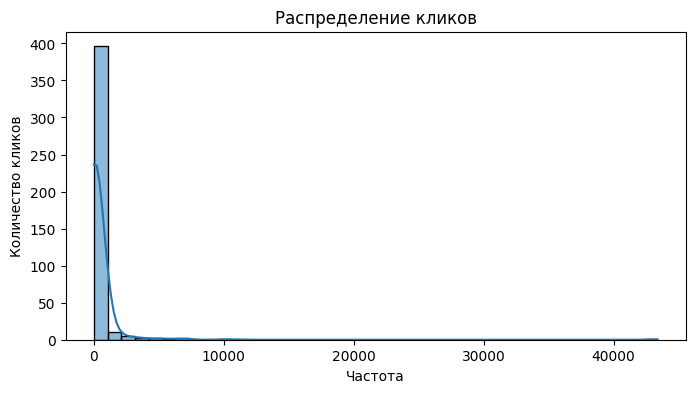

In [ ]:

plt.figure(figsize=(8, 4))
sns.histplot(df, x='n_click', kde=True)
plt.title('Распределение кликов')
plt.ylabel('Количество кликов')
plt.xlabel('Частота')
plt.show()

In [13]:
# уже здесь мы можем заметить, что в данных есть выбросы (т.к. частота достигает 40000). скорее всего ттест будет нас обманывать, посмотрим дальше...

In [14]:
def aa_test(signals, n_iter=5000):
    pvals_ttest = []
    pvals_mw = []
    
    for _ in range(n_iter):
        group_a = np.random.choice(signals, size=210, replace=True)
        group_b = np.random.choice(signals, size=210, replace=True)
        
        pvals_ttest.append(stats.ttest_ind(group_a, group_b)[1])
        pvals_mw.append(stats.mannwhitneyu(group_a, group_b)[1])
    
    return np.array(pvals_ttest), np.array(pvals_mw)

pvals_ttest, pvals_mw = aa_test(df['n_click'])

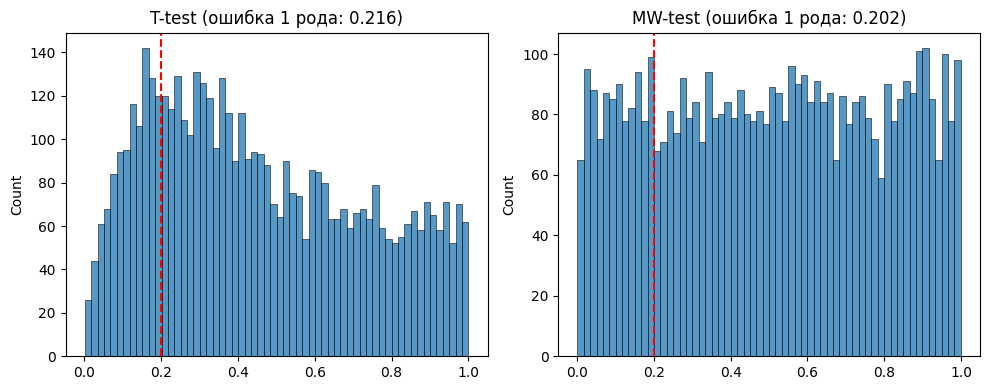

In [15]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(pvals_ttest, bins=60)
plt.title(f'T-test (ошибка 1 рода: {np.mean(pvals_ttest < 0.2):.3f})')
plt.axvline(0.2, color='red', linestyle='--')

plt.subplot(1, 2, 2)
sns.histplot(pvals_mw, bins=60)
plt.title(f'MW-test (ошибка 1 рода: {np.mean(pvals_mw < 0.2):.3f})')
plt.axvline(0.2, color='red', linestyle='--')

plt.tight_layout()
plt.show()

In [16]:
# Как видим ttest действительно неравномерно распределил p_value. 
# Из-за переодически появляющегося выброса ttest чаще показывает p_value < alpha, тем самым говоря нам ,,Отвергаем H0! Эффект от новой фичи есть,, хотя на самом деле его может не быть.
# В то время как mwtest на заведомо "равноценных" выборках показад, что p_value распределен равномерно(что и ожидалось) и не подвержен выбросам.

In [17]:
# Так что, хотя fpr и одинаковый и примерно равен alpha, но опасность, что ttest обманет нас при реальной проверке на самом деле выше, 
# чем опасность обмана от mw теста.

#Таким образом я бы сказал, что целесообразно использовать MW-test как статкритерий при АБ тестировании.